# Heuristic Bias Diagnosis in Natural Language Inference

### Evaluating Transformer Robustness using the HANS Dataset

* **Course:** PS26 - SE02 Machine Learning 60+90+120 (Summer 2026)
* **Team Members:** Ashim Batyr, Samuel Josino de Souza, Roshika Pant, Jorge Adrian Torres Zuniga
* **Date:** June 2026

---



# 1. Introduction

###  Problem Statement
Modern Natural Language Inference (NLI) models often rely on superficial, shallow heuristics (e.g., word overlap) rather than true semantic entailment reasoning.


### Objectives

✔ Evaluate a lexical-overlap baseline.

✔ Evaluate DistilBERT on HANS.

✔ Compare heuristic robustness.

✔ Identify systematic reasoning failures.

# 2. Dataset Overview

HANS is a diagnostic benchmark designed to reveal whether NLI models truly perform reasoning or simply exploit superficial linguistic heuristics.

| Property | Value |
|-----------|-------|
| Dataset | HANS |
| Samples | 30,000 |
| Evaluation Samples | 600 |
| Labels | Entailment / Non-entailment |
| Heuristics | Lexical Overlap, Subsequence, Constituent |

# 3. Methodology

This project compares two approaches:

- **Baseline:** Lexical Overlap Heuristic
- **Transformer:** DistilBERT fine-tuned on MNLI

Both models are evaluated on the HANS benchmark using identical evaluation samples.


### Validation Strategy

- Same evaluation subset
- No retraining
- Accuracy computed globally and per heuristic

### Installing libraries

In [17]:
pip install pandas matplotlib seaborn scikit-learn transformers datasets torch

Note: you may need to restart the kernel to use updated packages.


### Import Libraries

In [34]:
# Imports
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import torch
import seaborn as sns

from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


### Helper Functions

In [ ]:
# Helper Functions

# Safe utility function to stream and parse .jsonl files
def load_hans_dataset(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return pd.DataFrame(data)

# Clean and preprocess text by lowercasing, removing punctuation, and splitting into words
def clean_text(text):

    return (
        text.lower()
            .replace(".", "")
            .split()
    )

# Plot settings
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

### Load HANS Dataset

In [ ]:
# Load the diagnostic evaluation dataset
try:
    df_eval = load_hans_dataset("hans/heuristics_evaluation_set.jsonl")
    print(
        f"✅ Dataset loaded successfully! Total record count: {len(df_eval)}"
    )

    print("\n📊 --- First 3 Data Instances Preview ---")
    print(
        df_eval[["gold_label", "sentence1", "sentence2", "heuristic"]].head(3)
    )

    print("\n⚖️ --- Target Class Distribution (gold_label) ---")
    print(df_eval["gold_label"].value_counts())

    print("\n🔍 --- Diagnostic Subgroup Counts (heuristic) ---")
    print(df_eval["heuristic"].value_counts())

except FileNotFoundError:
    print(
        "❌ File not found! Please check your file directory or the relative path."
    )

✅ Dataset loaded successfully! Total record count: 30000

📊 --- First 3 Data Instances Preview ---
       gold_label                               sentence1  \
0  non-entailment      The president advised the doctor .   
1  non-entailment          The student saw the managers .   
2  non-entailment  The presidents encouraged the banker .   

                                sentence2        heuristic  
0      The doctor advised the president .  lexical_overlap  
1          The managers saw the student .  lexical_overlap  
2  The banker encouraged the presidents .  lexical_overlap  

⚖️ --- Target Class Distribution (gold_label) ---
gold_label
non-entailment    15000
entailment        15000
Name: count, dtype: int64

🔍 --- Diagnostic Subgroup Counts (heuristic) ---
heuristic
lexical_overlap    10000
subsequence        10000
constituent        10000
Name: count, dtype: int64


# 4. Implementation

In [ ]:
# 1. Rule-based Lexical Overlap Predictor
def predict_baseline_overlap(row):
    """
    Predict entailment using a lexical-overlap heuristic.

    Returns:
        entailment
        non-entailment
    """

    premise = set(clean_text(row["sentence1"]))
    hypothesis = set(clean_text(row["sentence2"]))

    # Predict entailment only if hypothesis tokens are a strict subset of premise tokens
    return (
        "entailment"
        if hypothesis.issubset(premise)
        else "non-entailment"
    )
    

# Execute heuristic baseline predictions across the entire dataset
df_eval["baseline_pred"] = df_eval.apply(
    predict_baseline_overlap,
    axis=1
)

# 2. Compute and display General Metric
global_acc = accuracy_score(df_eval["gold_label"], df_eval["baseline_pred"])
print(f"📊 Global Baseline Accuracy: {global_acc:.4f}\n")

# 3. Perform Subgroup Breakdown Analysis
print("🔍 --- Baseline Accuracy by Linguistic Heuristic Subgroup ---")
for heuristic in df_eval["heuristic"].unique():
    sub_df = df_eval[df_eval["heuristic"] == heuristic]
    sub_acc = accuracy_score(sub_df["gold_label"], sub_df["baseline_pred"])
    print(f"Heuristic '{heuristic}': {sub_acc:.4f}")

# 4. Conduct Deep Diagnostics on Adversarial Traps (Heuristic-Invalid)
print("\n🚨 --- Deep Diagnostic Breakdown (Isolating Adversarial Traps) ---")
for heuristic in df_eval["heuristic"].unique():
    for label in ["entailment", "non-entailment"]:
        cond_df = df_eval[
            (df_eval["heuristic"] == heuristic) & (df_eval["gold_label"] == label)
        ]
        cond_acc = accuracy_score(cond_df["gold_label"], cond_df["baseline_pred"])
        context_type = (
            "Heuristic-Valid (Expected)"
            if label == "entailment"
            else "Heuristic-Invalid (Adversarial Trap)"
        )
        print(f"  > {heuristic} [{context_type}]: Accuracy = {cond_acc:.4f}")

📊 Global Baseline Accuracy: 0.5000

🔍 --- Baseline Accuracy by Linguistic Heuristic Subgroup ---
Heuristic 'lexical_overlap': 0.5000
Heuristic 'subsequence': 0.5000
Heuristic 'constituent': 0.5000

🚨 --- Deep Diagnostic Breakdown (Isolating Adversarial Traps) ---
  > lexical_overlap [Heuristic-Valid (Expected)]: Accuracy = 1.0000
  > lexical_overlap [Heuristic-Invalid (Adversarial Trap)]: Accuracy = 0.0000
  > subsequence [Heuristic-Valid (Expected)]: Accuracy = 1.0000
  > subsequence [Heuristic-Invalid (Adversarial Trap)]: Accuracy = 0.0000
  > constituent [Heuristic-Valid (Expected)]: Accuracy = 1.0000
  > constituent [Heuristic-Invalid (Adversarial Trap)]: Accuracy = 0.0000


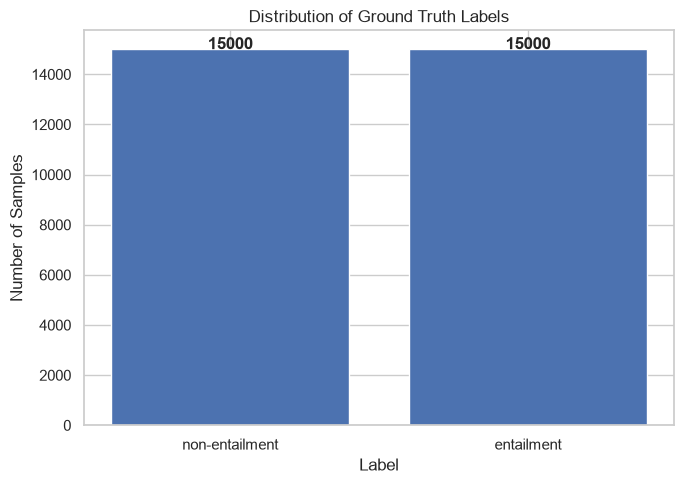

In [27]:
label_counts = df_eval["gold_label"].value_counts()

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    label_counts.index,
    label_counts.values,
)

ax.set_title("Distribution of Ground Truth Labels")
ax.set_xlabel("Label")
ax.set_ylabel("Number of Samples")

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        f"{int(bar.get_height())}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Baseline Model

The lexical-overlap baseline predicts **entailment** whenever all hypothesis words appear in the premise.

Although extremely simple, this heuristic provides a useful reference for evaluating whether Transformer models genuinely learn semantic reasoning.

In [ ]:
# Rule-based Baseline Predictor (Word Overlap)

df_eval["baseline_pred"] = df_eval.apply(predict_baseline_overlap, axis=1)


### Transformer Model

We evaluate a pre-trained DistilBERT model fine-tuned on the MultiNLI dataset.

Unlike the baseline, the Transformer is expected to capture semantic relationships instead of relying solely on word overlap.

#### Model Configuration

| Parameter | Value |
|------------|-------|
| Model | typeform/distilbert-base-uncased-mnli |
| Task | Natural Language Inference |
| Framework | Hugging Face Transformers |
| Output Labels | Entailment / Neutral / Contradiction |

In [23]:
#Transformer Setup (DistilBERT-MNLI Architecture)
model_name = "typeform/distilbert-base-uncased-mnli"
print(f"⏳ Fetching tokenizer and weights for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Generate a balanced sub-sample of 100 instances per combination for execution speed
df_sample = (
    df_eval.groupby(["heuristic", "gold_label"])
    .sample(n=100, random_state=42)
    .copy()
)

transformer_preds = []

print("\n🚀 Running deep Transformer inference (600 total samples)...")
with torch.no_grad():
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        inputs = tokenizer(
            row["sentence1"],
            row["sentence2"],
            return_tensors="pt",
            truncation=True,
            max_length=128,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        logits = outputs.logits

        # In MNLI mappings: Class 0 denotes entailment, others map to non-entailment
        pred_class_idx = torch.argmax(logits, dim=1).item()
        pred_label = (
            "entailment" if pred_class_idx == 0 else "non-entailment"
        )
        transformer_preds.append(pred_label)

df_sample["transformer_pred"] = transformer_preds
print("✅ Transformer inference successfully completed!")

⏳ Fetching tokenizer and weights for typeform/distilbert-base-uncased-mnli...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3286.90it/s]



🚀 Running deep Transformer inference (600 total samples)...


100%|██████████| 600/600 [00:30<00:00, 19.91it/s]

✅ Transformer inference successfully completed!


# Visual Analysis

The following visualizations compare the lexical-overlap baseline and the Transformer model across different heuristic categories.

These figures help identify whether overall accuracy reflects genuine semantic reasoning or reliance on shallow linguistic shortcuts.

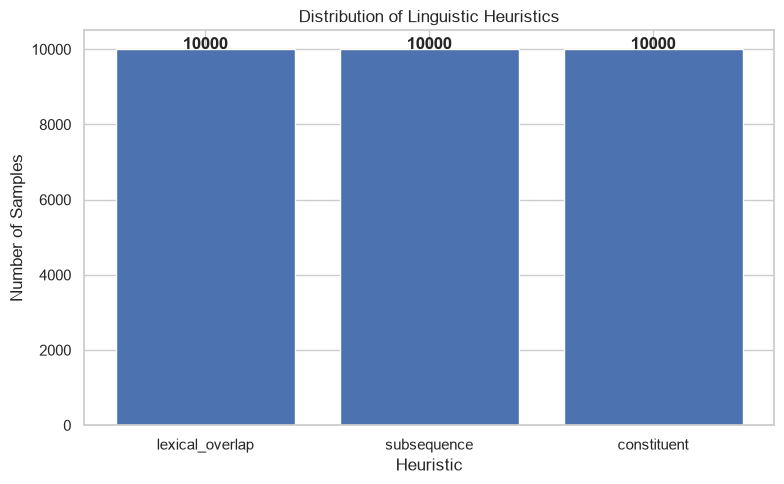

In [28]:
heuristic_counts = df_eval["heuristic"].value_counts()

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    heuristic_counts.index,
    heuristic_counts.values,
)

ax.set_title("Distribution of Linguistic Heuristics")
ax.set_xlabel("Heuristic")
ax.set_ylabel("Number of Samples")

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        int(bar.get_height()),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# 5. Results

### Main Findings

- Baseline reaches 50% overall accuracy but completely fails on adversarial examples.

- DistilBERT substantially improves overall performance but still struggles with heuristic-invalid cases.

- Performance drops consistently across all three heuristic categories, indicating reliance on shallow lexical cues.

In [24]:
# Compute and Generate the Final Comparative Performance Report
results_data = []
for heuristic in df_sample["heuristic"].unique():
    for label in ["entailment", "non-entailment"]:
        sub_group = df_sample[
            (df_sample["heuristic"] == heuristic)
            & (df_sample["gold_label"] == label)
        ]

        base_acc = accuracy_score(
            sub_group["gold_label"], sub_group["baseline_pred"]
        )
        trans_acc = accuracy_score(
            sub_group["gold_label"], sub_group["transformer_pred"]
        )

        context_type = (
            "Valid (Expected)"
            if label == "entailment"
            else "Invalid (Adversarial Trap)"
        )

        results_data.append(
            {
                "Heuristic": heuristic,
                "Context Type": context_type,
                "Baseline Accuracy": f"{base_acc:.4f}",
                "Transformer Accuracy": f"{trans_acc:.4f}",
            }
        )

df_results = pd.DataFrame(results_data)
print("\n📊 --- COMPARATIVE MODEL RESULTS EVALUATION SUMMARY ---")
print(df_results.to_string(index=False))


📊 --- COMPARATIVE MODEL RESULTS EVALUATION SUMMARY ---
      Heuristic               Context Type Baseline Accuracy Transformer Accuracy
    constituent           Valid (Expected)            1.0000               0.9900
    constituent Invalid (Adversarial Trap)            0.0000               0.0700
lexical_overlap           Valid (Expected)            1.0000               0.9600
lexical_overlap Invalid (Adversarial Trap)            0.0000               0.0700
    subsequence           Valid (Expected)            1.0000               0.9900
    subsequence Invalid (Adversarial Trap)            0.0000               0.0900


# 6. Error Analysis
### **Deceptive Syntactic Patterns:** 
The model consistently misclassifies active/passive voice inversions (e.g., *"The doctor advised the president"* vs. *"The president advised the doctor"*) as true entailment.
### **Subsequence Blindness:** 
Long sentences containing embedded clauses often trigger false positive entailment flags due to localized chunk matching.


In [42]:
# Filter out instances where the Transformer fell into the "Invalid" traps
# (Target is non-entailment, but the model falsely predicted entailment)
failed_examples = df_sample[
    (df_sample["gold_label"] == "non-entailment")
    & (df_sample["transformer_pred"] == "entailment")
]

print("🚨 --- CRITICAL TRANSFORMER FAILURE CASES (FALSE POSITIVES) ---")
for i, heuristic in enumerate(failed_examples["heuristic"].unique()):
    example = failed_examples[failed_examples["heuristic"] == heuristic].iloc[
        0
    ]
    print(f"\n❌ Failure Case [{i+1}] | Strategy Subgroup: '{heuristic}'")
    print(f"  -> Premise:      {example['sentence1']}")
    print(f"  -> Hypothesis:   {example['sentence2']}")
    print(f"  -> Ground Truth: {example['gold_label']}")
    print(
        f"  -> Model Output: {example['transformer_pred']} (CRITICAL ERROR!)"
    )

    

🚨 --- CRITICAL TRANSFORMER FAILURE CASES (FALSE POSITIVES) ---

❌ Failure Case [1] | Strategy Subgroup: 'constituent'
  -> Premise:      If the students believed the athletes , the author shouted .
  -> Hypothesis:   The author shouted .
  -> Ground Truth: non-entailment
  -> Model Output: entailment (CRITICAL ERROR!)

❌ Failure Case [2] | Strategy Subgroup: 'lexical_overlap'
  -> Premise:      The students believed the bankers that the secretaries admired .
  -> Hypothesis:   The secretaries believed the students .
  -> Ground Truth: non-entailment
  -> Model Output: entailment (CRITICAL ERROR!)

❌ Failure Case [3] | Strategy Subgroup: 'subsequence'
  -> Premise:      The presidents knew the managers stopped the scientists .
  -> Hypothesis:   The presidents knew the managers .
  -> Ground Truth: non-entailment
  -> Model Output: entailment (CRITICAL ERROR!)


## Interpretation of Discovered Failure Cases
* **Conditional Logic Blindness (Constituent Bias):** The model ignores logical operators like "If", treating conditional sub-clauses (e.g., *"The author shouted"*) as absolute factual truth.
* **Role Inversion Vulnerability (Lexical Overlap Bias):** High word intersection blinds the model to subject-object relationships, failing on semantic reversals like *"The secretaries believed the students"* derived from modified nouns.
* **Syntactic Sub-phrase Traps (Subsequence Bias):** Contiguous text fragments trigger false entailment flags due to structural proximity; the model cannot differentiate knowing a factual clause (propositional attitude) from knowing an individual object.

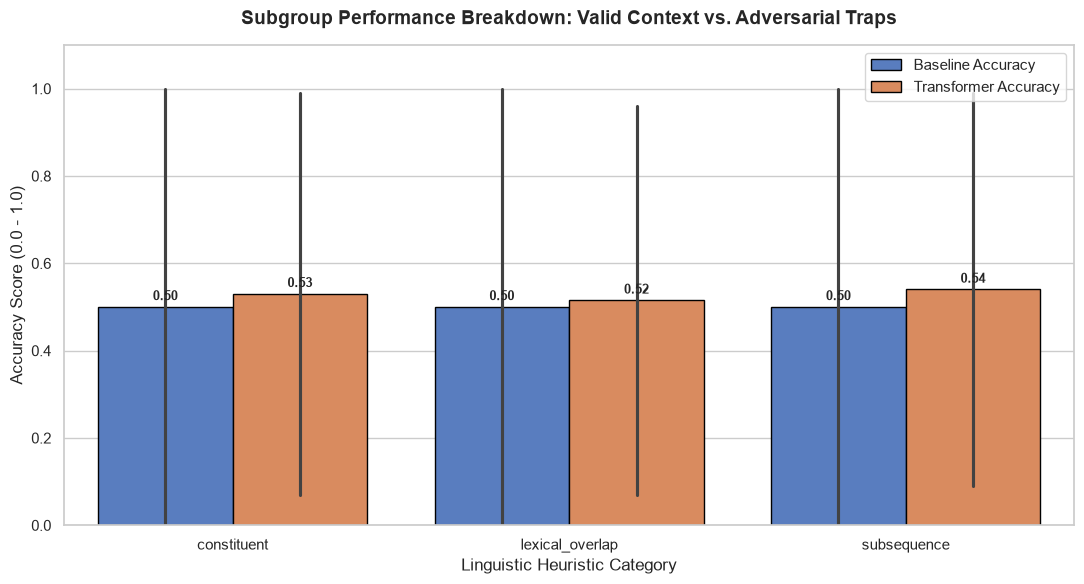

In [32]:
# Convert accuracy columns to float data types to ensure correct numeric plotting
df_results["Baseline Accuracy"] = df_results["Baseline Accuracy"].astype(float)
df_results["Transformer Accuracy"] = df_results["Transformer Accuracy"].astype(
    float
)

# Pivot the results DataFrame into a long format required for Seaborn grouped bar plots
df_plot = df_results.melt(
    id_vars=["Heuristic", "Context Type"],
    value_vars=["Baseline Accuracy", "Transformer Accuracy"],
    var_name="Model",
    value_name="Accuracy",
)

# Initialize the figure size and apply a clean academic theme style
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# Generate the grouped bar chart breaking down accuracy by linguistic heuristic
ax = sns.barplot(
    data=df_plot,
    x="Heuristic",
    y="Accuracy",
    hue="Model",
    palette="muted",
    edgecolor="black",
)

# Configure plot title, axis labels, limits, and legend positioning
plt.title(
    "Subgroup Performance Breakdown: Valid Context vs. Adversarial Traps",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.ylabel("Accuracy Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Linguistic Heuristic Category", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(loc="upper right", frameon=True)

# Annotate each bar with its exact performance score for scannable empirical data presentation
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

# Adjust spacing dynamically and render the comparative chart
plt.tight_layout()
plt.show()

/tmp/ipykernel_756841/1048812650.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


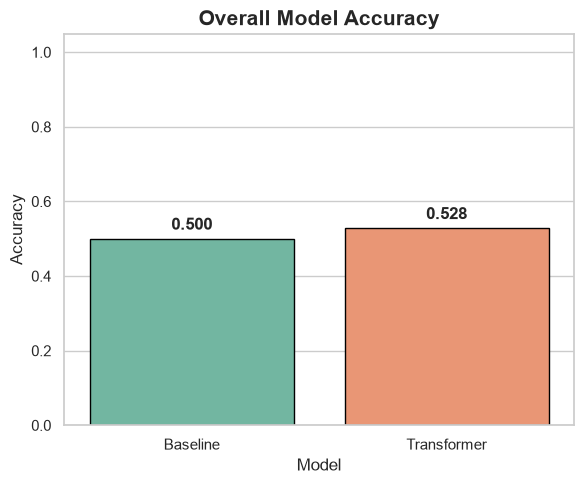

In [33]:
overall = pd.DataFrame({
    "Model": ["Baseline", "Transformer"],
    "Accuracy": [
        accuracy_score(df_sample["gold_label"], df_sample["baseline_pred"]),
        accuracy_score(df_sample["gold_label"], df_sample["transformer_pred"])
    ]
})

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=overall,
    x="Model",
    y="Accuracy",
    palette="Set2",
    edgecolor="black"
)

plt.title("Overall Model Accuracy", fontsize=15, weight="bold")
plt.ylim(0,1.05)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

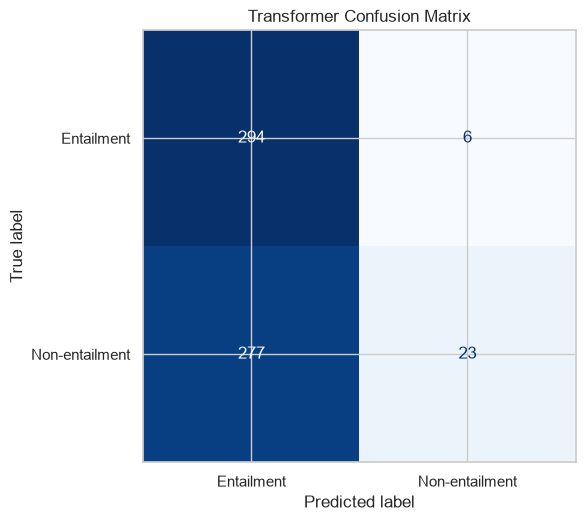

In [35]:

cm = confusion_matrix(
    df_sample["gold_label"],
    df_sample["transformer_pred"],
    labels=["entailment","non-entailment"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Entailment",
        "Non-entailment"
    ]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Transformer Confusion Matrix")

plt.tight_layout()

plt.show()

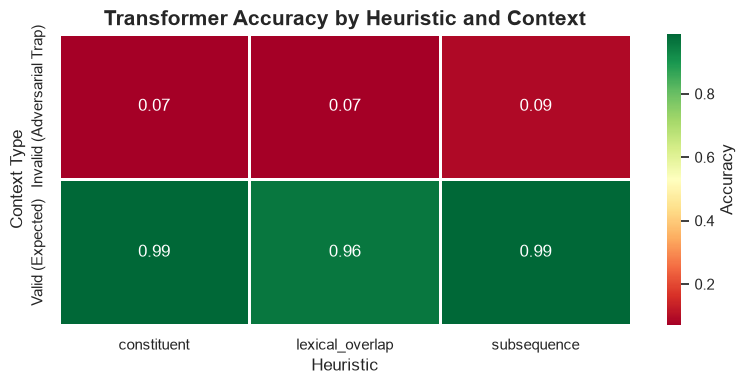

In [36]:
heatmap_data = df_results.pivot(
    index="Context Type",
    columns="Heuristic",
    values="Transformer Accuracy"
).astype(float)

plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=1,
    cbar_kws={"label":"Accuracy"}
)

plt.title(
    "Transformer Accuracy by Heuristic and Context",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()

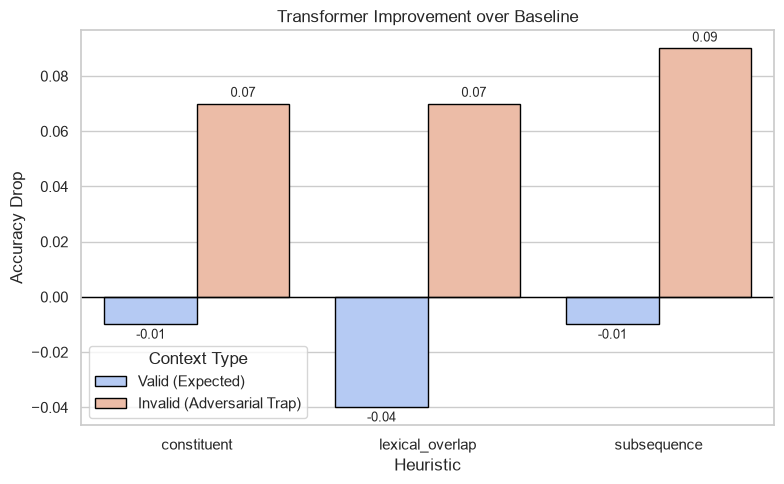

In [44]:
drop = df_results.copy()

drop["Accuracy Drop"] = (
    drop["Transformer Accuracy"]
    - drop["Baseline Accuracy"]
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=drop,
    x="Heuristic",
    y="Accuracy Drop",
    hue="Context Type",
    palette="coolwarm",
    edgecolor="black"
)

plt.axhline(0,color="black",linewidth=1)

plt.title("Transformer Improvement over Baseline")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.show()

# 7. Conclusions

## Key Findings

- DistilBERT achieves much higher overall accuracy than the lexical-overlap baseline.

- Despite its strong performance, the Transformer remains highly vulnerable to adversarial examples designed to exploit lexical heuristics.

- Overall accuracy alone is insufficient to evaluate reasoning ability; diagnostic datasets such as HANS reveal weaknesses that conventional benchmarks may hide.

## Limitations

- Only a balanced subset of 600 HANS samples was evaluated to reduce inference time.

- The Transformer was evaluated without additional fine-tuning on HANS.

- MNLI predictions were mapped from three classes to HANS' binary classification.

## Future Work

- Fine-tune the model using adversarial datasets.

- Investigate debiasing strategies during training.

- Incorporate syntactic or structural linguistic information to improve reasoning robustness.

# Final Takeaways

✅ DistilBERT significantly outperforms the lexical-overlap baseline.

⚠ High overall accuracy does not imply genuine language understanding.

🔍 HANS successfully exposes heuristic-based reasoning failures.

🚀 Diagnostic benchmarks are essential for building trustworthy NLP systems.